# 01 — Exploration des données

Objectif : comprendre la structure des données, la distribution de la cible et les caractéristiques des capteurs par classe.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [2]:
from src.data.load import load_ps2, load_fs1, load_profile, load_target

ps2     = load_ps2()
fs1     = load_fs1()
profile = load_profile()
y       = load_target()

print(f'PS2    : {ps2.shape}  (cycles × points à 100 Hz)')
print(f'FS1    : {fs1.shape}  (cycles × points à 10 Hz)')
print(f'Profile: {profile.shape}')
print(f'Target : {y.shape}')

PS2    : (2205, 6000)  (cycles × points à 100 Hz)
FS1    : (2205, 600)  (cycles × points à 10 Hz)
Profile: (2205, 5)
Target : (2205,)


## 1. Profile — toutes les variables système

In [3]:
profile.describe()

,cooler_condition,valve_condition,internal_pump_leakage,hydraulic_accumulator,stable_flag
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,41.240816,90.693878,0.669388,107.199546,0.342857
std,42.383143,10.681802,0.817233,16.435848,0.474772
min,3.000000,73.000000,0.000000,90.000000,0.000000
25%,3.000000,80.000000,0.000000,90.000000,0.000000
50%,20.000000,100.000000,0.000000,100.000000,0.000000
75%,100.000000,100.000000,1.000000,130.000000,1.000000
max,100.000000,100.000000,2.000000,130.000000,1.000000


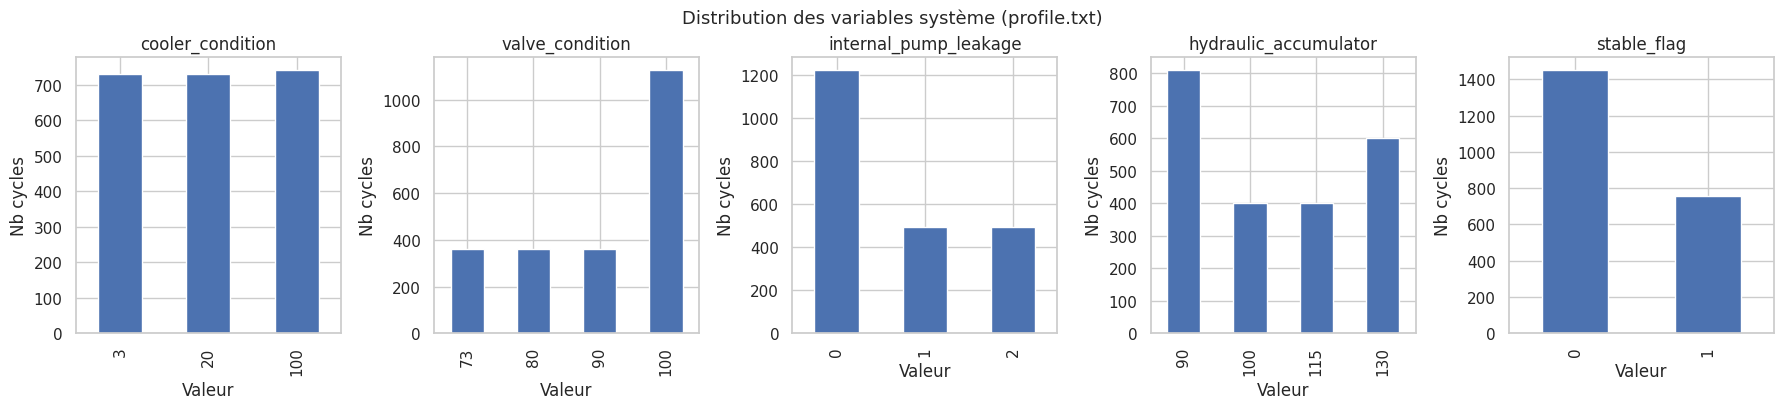

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, profile.columns):
    profile[col].value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Nb cycles')
plt.tight_layout()
plt.suptitle('Distribution des variables système (profile.txt)', y=1.02, fontsize=13)
plt.show()

## 2. Variable cible — valve_condition

In [5]:
vc = profile['valve_condition'].value_counts().sort_index()
print('Distribution valve_condition :')
for val, count in vc.items():
    pct = count / len(profile) * 100
    label = 'optimal' if val == 100 else 'non-optimal'
    print(f'  {val:3d}%  ({label})  → {count:4d} cycles  ({pct:.1f}%)')

print(f'\nCible binaire  →  optimal (1) : {y.sum()}  |  non-optimal (0) : {(y==0).sum()}')
print(f'Ratio          →  {y.mean():.2%} de cycles optimaux')

Distribution valve_condition :
   73%  (non-optimal)  →  360 cycles  (16.3%)
   80%  (non-optimal)  →  360 cycles  (16.3%)
   90%  (non-optimal)  →  360 cycles  (16.3%)
  100%  (optimal)  → 1125 cycles  (51.0%)

Cible binaire  →  optimal (1) : 1125  |  non-optimal (0) : 1080
Ratio          →  51.02% de cycles optimaux


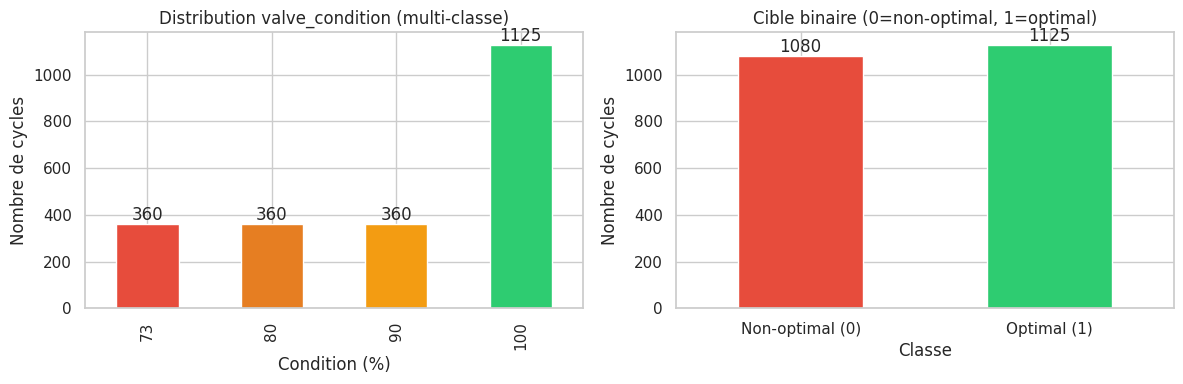

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

vc.plot(kind='bar', ax=ax1, color=['#e74c3c','#e67e22','#f39c12','#2ecc71'])
ax1.set_title('Distribution valve_condition (multi-classe)')
ax1.set_xlabel('Condition (%)')
ax1.set_ylabel('Nombre de cycles')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')

y.value_counts().sort_index().plot(kind='bar', ax=ax2, color=['#e74c3c','#2ecc71'])
ax2.set_title('Cible binaire (0=non-optimal, 1=optimal)')
ax2.set_xlabel('Classe')
ax2.set_ylabel('Nombre de cycles')
ax2.set_xticklabels(['Non-optimal (0)', 'Optimal (1)'], rotation=0)
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 3. Visualisation des capteurs par classe

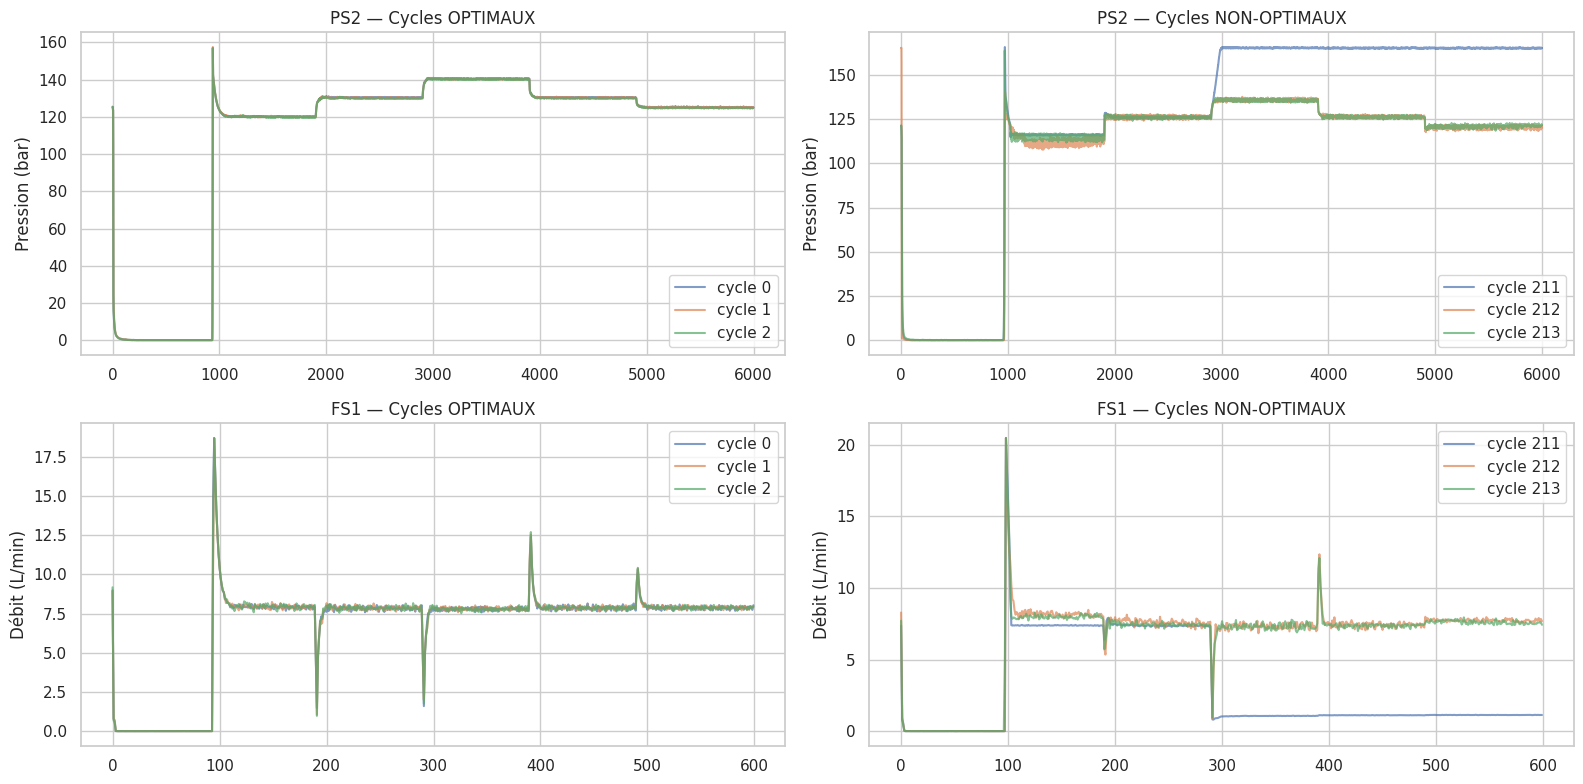

In [7]:
idx_opt     = np.where(y == 1)[0][:3]
idx_nonopt  = np.where(y == 0)[0][:3]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for i, idx in enumerate(idx_opt):
    axes[0, 0].plot(ps2[idx], alpha=0.7, label=f'cycle {idx}')
for i, idx in enumerate(idx_nonopt):
    axes[0, 1].plot(ps2[idx], alpha=0.7, label=f'cycle {idx}')
for i, idx in enumerate(idx_opt):
    axes[1, 0].plot(fs1[idx], alpha=0.7, label=f'cycle {idx}')
for i, idx in enumerate(idx_nonopt):
    axes[1, 1].plot(fs1[idx], alpha=0.7, label=f'cycle {idx}')

axes[0, 0].set_title('PS2 — Cycles OPTIMAUX');     axes[0, 0].set_ylabel('Pression (bar)')
axes[0, 1].set_title('PS2 — Cycles NON-OPTIMAUX'); axes[0, 1].set_ylabel('Pression (bar)')
axes[1, 0].set_title('FS1 — Cycles OPTIMAUX');     axes[1, 0].set_ylabel('Débit (L/min)')
axes[1, 1].set_title('FS1 — Cycles NON-OPTIMAUX'); axes[1, 1].set_ylabel('Débit (L/min)')

for ax in axes.flat:
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Statistiques descriptives par classe

In [8]:
for sensor, data, hz in [('PS2', ps2, 100), ('FS1', fs1, 10)]:
    means_opt    = data[y == 1].mean(axis=1)
    means_nonopt = data[y == 0].mean(axis=1)
    print(f'\n{sensor} — moyenne par cycle:')
    print(f'  Optimal     : {means_opt.mean():.3f} ± {means_opt.std():.3f}')
    print(f'  Non-optimal : {means_nonopt.mean():.3f} ± {means_nonopt.std():.3f}')


PS2 — moyenne par cycle:
  Optimal     : 108.771 ± 3.864
  Non-optimal : 110.014 ± 5.866

FS1 — moyenne par cycle:
  Optimal     : 6.410 ± 0.789
  Non-optimal : 5.979 ± 1.198


## 5. Corrélation entre les variables du profile

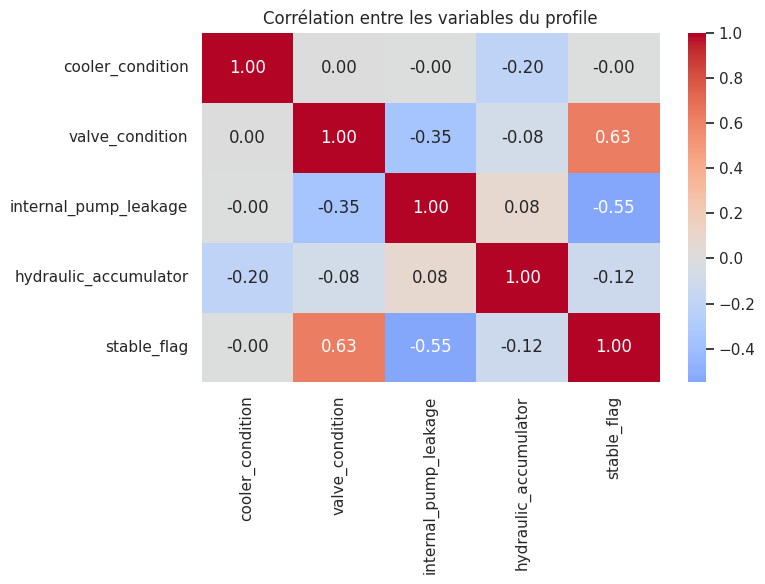

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(profile.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Corrélation entre les variables du profile')
plt.tight_layout()
plt.show()

## Conclusions

- **2205 cycles** au total : 2000 train, 205 test
- **Cible** : légèrement déséquilibrée (~52% optimal, ~48% non-optimal) — F1-score comme métrique principale
- **Valeurs de valve_condition** : {100, 90, 80, 73} → binarisé en 100% vs reste
- Les cycles PS2/FS1 montrent des profils visuellement similaires entre classes → features statistiques et FFT nécessaires pour discriminer